## From Swap Coupling to Geometric Coupling on Product Manifolds

The operator $[(1-\sigma)I + \sigma P]$ is not geometrically invariant because the permutation matrix $P$ is defined by its action on coordinate components in a fixed basis. If we change coordinates, the components of a vector field transform by the Jacobian, but $P$ does not transform accordingly. The notion of "swapping the $x$ and $y$ components" is tied to the coordinate chart, not to the geometry of the state space.

To obtain a coordinate-independent coupling that can operate on two distinct time variables, we move from the single manifold $\mathbb{R}^n$ to a **product manifold** and replace the discrete permutation with a **metric-compatible rotation**.

---

### 1. Setup: Two processes on a product manifold

Let $(M_1, g_1)$ and $(M_2, g_2)$ be smooth Riemannian manifolds representing two physical processes (e.g., earthquake magnitude space and flood discharge space), each with its own time parameter, $\tau_1$ and $\tau_2$. Let $X \in \mathfrak{X}(M_1)$ and $Y \in \mathfrak{X}(M_2)$ be the uncoupled vector fields.

Form the product manifold $\mathcal{M} = M_1 \times M_2$ with the product metric $g = g_1 \oplus g_2$. Denote by $\tilde{X}, \tilde{Y} \in \mathfrak{X}(\mathcal{M})$ the natural lifts of $X$ and $Y$. At each point $p \in \mathcal{M}$, the vectors $\tilde{X}_p$ and $\tilde{Y}_p$ span a 2-dimensional subspace $\Pi_p \subset T_p\mathcal{M}$.

---

### 2. Definition: Metric rotation coupling

Let $\theta \in [0, \pi/2]$ be the **coupling angle**. Define $R_\theta: T_p\mathcal{M} \to T_p\mathcal{M}$ as the rotation by angle $\theta$ in the plane $\Pi_p$ that leaves the orthogonal complement $\Pi_p^\perp$ fixed. With respect to any $g$-orthonormal basis $\{\hat{e}_1, \hat{e}_2\}$ of $\Pi_p$,
$$
R_\theta(\hat{e}_1) = \cos\theta\, \hat{e}_1 + \sin\theta\, \hat{e}_2, \qquad
R_\theta(\hat{e}_2) = -\sin\theta\, \hat{e}_1 + \cos\theta\, \hat{e}_2.
$$

The **geometrically coupled vector fields** are
$$
\tilde{X}^{(\theta)} = \cos\theta\, \tilde{X} + \sin\theta\, \tilde{Y}, \qquad
\tilde{Y}^{(\theta)} = -\sin\theta\, \tilde{X} + \cos\theta\, \tilde{Y}.
$$

Because $R_\theta$ is defined by the metric $g$ and the vectors themselves, it is independent of the coordinate chart. Under any diffeomorphism $\phi: \mathcal{M} \to \mathcal{M}$, the pushforward satisfies $\phi_* \circ R_\theta = R_\theta \circ \phi_*$.

---

### 3. Two-time dynamics

The uncoupled dynamics on $\mathcal{M}$ with independent time parameters is described by a parametrized surface $\Phi(t_1, t_2)$ satisfying
$$
\frac{\partial \Phi}{\partial t_1} = \tilde{X}, \qquad \frac{\partial \Phi}{\partial t_2} = \tilde{Y},
$$
subject to the Frobenius integrability condition $[\tilde{X}, \tilde{Y}] = 0$.

Under geometric coupling, the two-time dynamics becomes
$$
\frac{\partial \Phi}{\partial t_1} = \tilde{X}^{(\theta)}, \qquad \frac{\partial \Phi}{\partial t_2} = \tilde{Y}^{(\theta)}.
$$

The coupling angle $\theta$ controls the mixing:
- $\theta = 0$: uncoupled product dynamics;
- $\theta = \pi/4$: equal-weight mixing in the $\Pi_p$ plane;
- $\theta = \pi/2$: the two vector fields are exchanged in a metric-compatible way.

---

### 4. Relation to the original swap matrix

In any coordinate chart where $\tilde{X} = (F_x, 0)$ and $\tilde{Y} = (0, F_y)$ with respect to an orthonormal frame, the rotation coupling reduces to
$$
\begin{pmatrix} \tilde{X}^{(\theta)} \\ \tilde{Y}^{(\theta)} \end{pmatrix}
=
\begin{pmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{pmatrix}
\begin{pmatrix} F_x \\ F_y \end{pmatrix}.
$$

This generalizes the swap matrix $P$ to a continuous, orientation-preserving rotation. Unlike $[(1-\sigma)I + \sigma P]$, which is a linear interpolation between matrices, the family $R_\theta$ is a one-parameter subgroup of $SO(T_p\mathcal{M}, g)$, the group of metric-preserving automorphisms of the tangent space.

---

### 5. Practical remark: the Euclidean case

In the common setting where $M_1 = M_2 = \mathbb{R}$ with the standard metric, the product manifold is $\mathbb{R}^2$ with the Euclidean metric. The plane $\Pi_p$ is simply the full tangent space $T_p\mathbb{R}^2 \cong \mathbb{R}^2$, and the rotation $R_\theta$ is the familiar matrix
$$
O(\theta) = \begin{pmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{pmatrix}.
$$

The coupled gradient descent update is then
$$
\begin{pmatrix} \Delta x_i^{\text{(coupled)}} \\ \Delta y_i^{\text{(coupled)}} \end{pmatrix}
=
O(\theta)
\begin{pmatrix} -\eta\, \partial_x f \\ -\eta\, \partial_y f \end{pmatrix},
$$
which is evaluated at the fixed point $(x_i, y_i)$ and is manifestly invariant under simultaneous rotation of both the state space and the gradient.

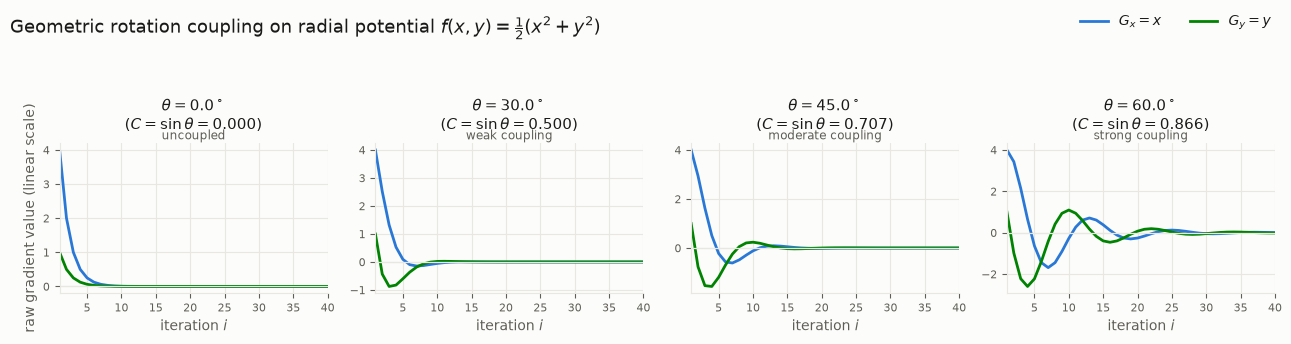

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- style constants ---
SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#1a1a19"
TEXT_SECONDARY = "#5f5e56"
GRID = "#e8e7e2"
C_GX = "#2a78d6"
C_GY = "#008300"

def grad_radial(x, y):
    """Gradient of f(x,y) = 0.5*(x^2 + y^2) is simply (x, y)."""
    return np.array([x, y], dtype=np.float64)

def geometric_coupled_descent(x0, y0, eta, n_steps, theta):
    x, y = float(x0), float(y0)
    Gx = np.empty(n_steps)
    Gy = np.empty(n_steps)

    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    for i in range(n_steps):
        gx, gy = grad_radial(x, y)
        Gx[i] = gx
        Gy[i] = gy

        inc = np.array([-eta * gx, -eta * gy])
        inc_rot = R @ inc

        x += float(inc_rot[0])
        y += float(inc_rot[1])

        if not (np.isfinite(x) and np.isfinite(y)):
            raise FloatingPointError(f"non-finite state at step {i+1}")

    C = float(np.sin(theta))
    return Gx, Gy, C

# --- build the figure ---
configs = [
    (0.000, "uncoupled"),
    (np.pi / 6, "weak coupling"),
    (np.pi / 4, "moderate coupling"),
    (np.pi / 3, "strong coupling"),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=False)
fig.patch.set_facecolor(SURFACE)
iterations = np.arange(1, 41)

for ax, (theta, desc) in zip(axes, configs):
    Gx, Gy, C = geometric_coupled_descent(4.0, 1.0, 0.5, 40, theta)

    ax.set_facecolor(SURFACE)
    ax.plot(iterations, Gx, color=C_GX, lw=2)
    ax.plot(iterations, Gy, color=C_GY, lw=2)
    ax.axhline(0.0, color=GRID, lw=0.9)

    theta_deg = np.degrees(theta)
    ax.set_title(
        rf"$\theta = {theta_deg:.1f}^\circ$" + "\n"
        rf"($C = \sin\theta = {C:.3f}$)",
        fontsize=11, color=TEXT_PRIMARY, pad=10,
    )
    ax.text(
        0.5, 1.005, desc, transform=ax.transAxes,
        ha="center", va="bottom", fontsize=8.5, color=TEXT_SECONDARY,
    )
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.set_xlabel("iteration $i$", fontsize=10, color=TEXT_SECONDARY)
    ax.set_xlim(1, 40)

axes[0].set_ylabel(
    "raw gradient value (linear scale)", fontsize=10, color=TEXT_SECONDARY
)

fig.legend(
    handles=[
        plt.Line2D([], [], color=C_GX, lw=2, label=r"$G_x = x$"),
        plt.Line2D([], [], color=C_GY, lw=2, label=r"$G_y = y$"),
    ],
    loc="upper right", ncol=2, frameon=False, fontsize=10,
    bbox_to_anchor=(0.99, 1.02), labelcolor=TEXT_PRIMARY,
)
fig.suptitle(
    "Geometric rotation coupling on radial potential "
    r"$f(x,y)=\frac{1}{2}(x^2+y^2)$",
    x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY,
)
fig.tight_layout(rect=[0, 0, 1, 0.90])

# Display inline (do not close the figure)
plt.show()

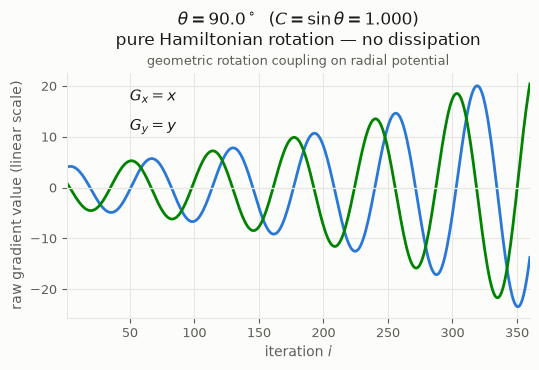

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- style constants ---
SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#1a1a19"
TEXT_SECONDARY = "#5f5e56"
GRID = "#e8e7e2"
C_GX = "#2a78d6"
C_GY = "#008300"

def grad_radial(x, y):
    """Gradient of f(x,y) = 0.5*(x^2 + y^2) is simply (x, y)."""
    return np.array([x, y], dtype=np.float64)

def geometric_coupled_descent(x0, y0, eta, n_steps, theta):
    x, y = float(x0), float(y0)
    Gx = np.empty(n_steps)
    Gy = np.empty(n_steps)

    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    for i in range(n_steps):
        gx, gy = grad_radial(x, y)
        Gx[i] = gx
        Gy[i] = gy

        inc = np.array([-eta * gx, -eta * gy])
        inc_rot = R @ inc

        x += float(inc_rot[0])
        y += float(inc_rot[1])

        if not (np.isfinite(x) and np.isfinite(y)):
            raise FloatingPointError(f"non-finite state at step {i+1}")

    C = float(np.sin(theta))
    return Gx, Gy, C

# --- build the single panel ---
theta = np.pi / 2
Gx, Gy, C = geometric_coupled_descent(4.0, 1.0, 0.10, 360, theta)
iterations = np.arange(1, 361)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.8))
fig.patch.set_facecolor(SURFACE)

ax.set_facecolor(SURFACE)
ax.plot(iterations, Gx, color=C_GX, lw=2)
ax.plot(iterations, Gy, color=C_GY, lw=2)
ax.axhline(0.0, color=GRID, lw=0.9)

theta_deg = np.degrees(theta)
ax.set_title(
    rf"$\theta = {theta_deg:.1f}^\circ$  ($C = \sin\theta = {C:.3f}$)" + "\n"
    "pure Hamiltonian rotation — no dissipation",
    fontsize=12, color=TEXT_PRIMARY, pad=20,
)
ax.text(
    0.5, 1.02, "geometric rotation coupling on radial potential",
    transform=ax.transAxes, ha="center", va="bottom",
    fontsize=9, color=TEXT_SECONDARY,
)
ax.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(GRID)
ax.tick_params(colors=TEXT_SECONDARY, labelsize=9)
ax.set_xlabel("iteration $i$", fontsize=10, color=TEXT_SECONDARY)
ax.set_ylabel("raw gradient value (linear scale)", fontsize=10, color=TEXT_SECONDARY)
ax.set_xlim(1, 360)

# annotations matching your original style
ax.annotate(r"$G_x = x$", xy=(30, Gx[29]), xytext=(50, max(Gx)*0.85),
            fontsize=11, color=TEXT_PRIMARY)
ax.annotate(r"$G_y = y$", xy=(30, Gy[29]), xytext=(50, max(Gy)*0.55),
            fontsize=11, color=TEXT_PRIMARY)

fig.tight_layout()

# Display inline (do not close the figure)
plt.show()